# FULCRUM — Campaign Decile Analysis

This is the bridge between the logistic regression model
([`src/models/train.py`](../src/models/train.py)) and the P&L
([`python/05_pnl.py`](../python/05_pnl.py)): score the held-out time-ordered
test set, rank clients by predicted probability, and report the standard
decile/gains table an analyst would use to decide how deep into a ranked call
list to actually dial.

**Base rate note, up front:** this test set's own subscription rate is
**38.4%**, not the dataset's overall **11.3%** (the time-ordered split's test
period is a macro downturn where clients converted far more than average —
see [`notebooks/02_split_strategy.ipynb`](02_split_strategy.ipynb)). Lift is
always relative to *the population the table describes*, which is this test
set, not the full multi-year history — so every Lift figure below is
computed against 38.4%, and the code asserts on this rather than silently
trusting it.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.train import fit_logistic_regression

BLUE, ORANGE, MUTED, GRID, AXIS, INK2, SURFACE = (
    "#2a78d6", "#eb6834", "#898781", "#e1e0d9", "#c3c2b7", "#52514e", "#fcfcfb",
)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "text.color": "#0b0b0b", "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10.5, "figure.dpi": 110,
})

## Score the held-out test set

`fit_logistic_regression` runs the same time-ordered split, scaling, and
logistic regression used throughout this project — this notebook doesn't
retrain anything differently, it just scores the resulting test set and
ranks it.

In [2]:
df = pd.read_csv("../data/processed/features.csv")
trained = fit_logistic_regression(df)

y_test = trained.y_test.reset_index(drop=True)
y_proba = trained.model.predict_proba(trained.X_test)[:, 1]

print(f"Test set: {len(y_test):,} rows")

Test set: 6,177 rows


In [3]:
# --- base rate: use the TEST set's own rate, not the full dataset's ---
overall_base_rate = df["y"].mean()      # all ~3 years, all regimes — NOT used below
test_base_rate = y_test.mean()          # this test period only — THIS is what Lift uses

print(f"Overall dataset base rate (all periods): {overall_base_rate:.1%}  <- NOT used for Lift")
print(f"Test-period base rate (this table's population): {test_base_rate:.1%}  <- used for Lift")

BASE_RATE = test_base_rate

# Guard against exactly the mistake this notebook is warning about: if BASE_RATE
# ever ends up equal to the whole-dataset rate instead of the test period's own
# rate, every Lift figure below would be quietly wrong. Fail loudly instead.
assert abs(BASE_RATE - overall_base_rate) > 0.05, (
    "BASE_RATE is suspiciously close to the whole-dataset rate — check this is "
    "the TEST set's own base rate, not the overall 11.3% figure."
)

Overall dataset base rate (all periods): 11.3%  <- NOT used for Lift
Test-period base rate (this table's population): 38.4%  <- used for Lift


## Build the decile table

Decile 1 = highest predicted probability, decile 10 = lowest — standard
campaign-analytics convention (the ranked call list starts at decile 1).
Deciles are cut on rank position after sorting by score, so every decile
gets an (as close as possible to) equal share of the test set regardless of
how scores cluster.

In [4]:
ranked = pd.DataFrame({"y_true": y_test.values, "y_proba": y_proba})
ranked = ranked.sort_values("y_proba", ascending=False).reset_index(drop=True)

n = len(ranked)
N_DECILES = 10
ranked["decile"] = (ranked.index * N_DECILES // n) + 1  # 1 = top-scored

agg = ranked.groupby("decile").agg(count=("y_true", "size"), actual_responders=("y_true", "sum"))
agg["response_rate"] = agg["actual_responders"] / agg["count"]
agg["lift"] = agg["response_rate"] / BASE_RATE

agg["cumulative_responders"] = agg["actual_responders"].cumsum()
cumulative_count = agg["count"].cumsum()
agg["cumulative_response_rate"] = agg["cumulative_responders"] / cumulative_count
agg["cumulative_lift"] = agg["cumulative_response_rate"] / BASE_RATE

total_responders = agg["actual_responders"].sum()
agg["cumulative_pct_of_responders"] = agg["cumulative_responders"] / total_responders * 100

decile_table = agg.reset_index().rename(columns={
    "decile": "Decile",
    "count": "Count",
    "actual_responders": "Actual Responders",
    "response_rate": "Response Rate",
    "lift": "Lift",
    "cumulative_responders": "Cumulative Responders",
    "cumulative_response_rate": "Cumulative Response Rate",
    "cumulative_lift": "Cumulative Lift",
    "cumulative_pct_of_responders": "Cumulative % of Total Responders",
})

display_table = decile_table.copy()
for col in ["Response Rate", "Cumulative Response Rate"]:
    display_table[col] = (display_table[col] * 100).round(1).astype(str) + "%"
for col in ["Lift", "Cumulative Lift"]:
    display_table[col] = display_table[col].round(2)
display_table["Cumulative % of Total Responders"] = display_table["Cumulative % of Total Responders"].round(1)

display_table

,Decile,Count,Actual Responders,Response Rate,Lift,Cumulative Responders,Cumulative Response Rate,Cumulative Lift,Cumulative % of Total Responders
0,1,618,303,49.0%,1.28,303,49.0%,1.28,12.8
1,2,618,286,46.3%,1.20,589,47.7%,1.24,24.8
2,3,618,262,42.4%,1.10,851,45.9%,1.19,35.8
3,4,617,305,49.4%,1.29,1156,46.8%,1.22,48.7
4,5,618,275,44.5%,1.16,1431,46.3%,1.20,60.3
5,6,618,239,38.7%,1.01,1670,45.0%,1.17,70.3
6,7,617,206,33.4%,0.87,1876,43.4%,1.13,79.0
7,8,618,172,27.8%,0.72,2048,41.4%,1.08,86.2
8,9,618,153,24.8%,0.64,2201,39.6%,1.03,92.7
9,10,617,174,28.2%,0.73,2375,38.4%,1.00,100.0


## Column naming — what you asked for vs. standard practice

Your seven requested columns map onto the table above as: **Decile, Count,
Actual Responders, Response Rate, Lift, Cumulative Responders, Cumulative
Lift.** One naming note and one structural gap:

- **"Lift versus base rate" → renamed to "Lift".** In every gains-table
  convention this column is just called `Lift` — the comparison to the base
  rate is what Lift *means* by definition, so spelling it out in the header
  is the one non-standard part of your naming. Not wrong, just redundant.
- **"Actual Responders"** is fine, though most published tables just say
  `Responders` or `# Responders` — "Actual" is only useful when a table also
  shows *predicted/expected* responders alongside it (a model-monitoring
  table, not this one), so it's an acceptable but non-essential qualifier here.
- **Two standard columns you didn't list, added anyway:**
  - `Cumulative Response Rate` — the direct cumulative-responders-over-
    cumulative-count ratio that `Cumulative Lift` is computed from. Most
    analysts expect to see it explicitly rather than only its ratio-to-base-rate form.
  - `Cumulative % of Total Responders` (often just called **Gain** or
    **Gain%**) — this is the column a gains chart's y-axis actually plots, so
    it wasn't optional once a gains chart was in scope; it's also one of the
    most standard columns in this kind of table, arguably the namesake one.

## Gains chart

Cumulative % of population targeted (x) vs. cumulative % of total responders
captured (y), against the diagonal a random (unranked) call list would trace.

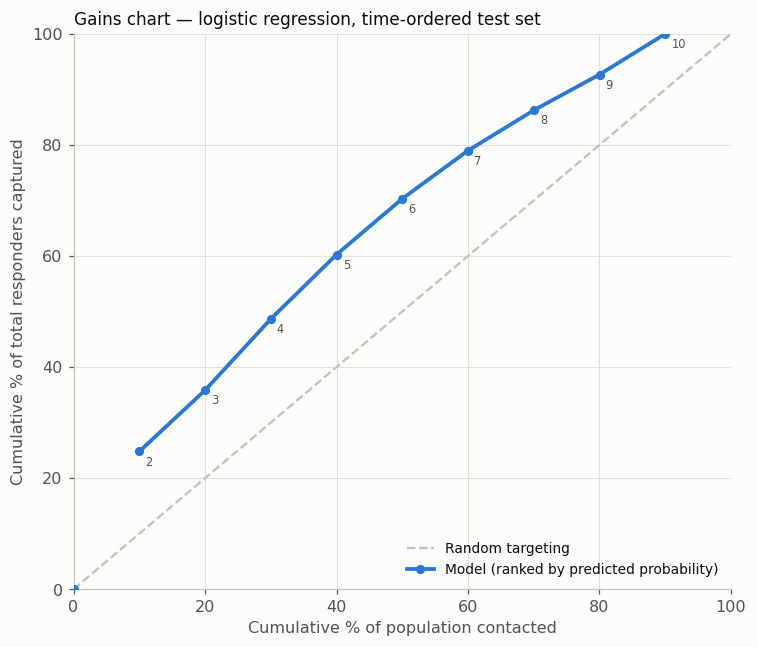

In [5]:
decile_table["Cumulative % of Population"] = cumulative_count / n * 100

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 100], [0, 100], color=AXIS, linewidth=1.5, linestyle="--", zorder=2, label="Random targeting")

x = pd.concat([pd.Series([0.0]), decile_table["Cumulative % of Population"]], ignore_index=True)
y = pd.concat([pd.Series([0.0]), decile_table["Cumulative % of Total Responders"]], ignore_index=True)
ax.plot(x, y, color=BLUE, linewidth=2.5, marker="o", markersize=5, zorder=3,
        label="Model (ranked by predicted probability)")

for _, row in decile_table.iterrows():
    ax.annotate(str(int(row["Decile"])),
                (row["Cumulative % of Population"], row["Cumulative % of Total Responders"]),
                textcoords="offset points", xytext=(4, -9), fontsize=7.5, color=INK2)

ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel("Cumulative % of population contacted")
ax.set_ylabel("Cumulative % of total responders captured")
ax.set_title("Gains chart — logistic regression, time-ordered test set", loc="left", fontsize=11)
ax.legend(loc="lower right", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Are the decile reversals real, or noise?

Decile 4 (49.4%) beat decile 1 (49.0%); decile 10 (28.2%) beat deciles 8
(27.8%) and 9 (24.8%). At n≈618 per decile, that could easily be sampling
noise rather than a genuine ranking failure — the only way to tell is a
confidence interval on each decile's response rate, not another point
estimate.

In [6]:
def wilson_ci(x, n, z=1.96):
    # Wilson score interval for a binomial proportion.
    p = x / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

ci = decile_table.apply(lambda r: wilson_ci(r["Actual Responders"], r["Count"]), axis=1)
decile_table["CI Lower"] = [c[0] for c in ci]
decile_table["CI Upper"] = [c[1] for c in ci]

ci_view = decile_table[["Decile", "Count", "Actual Responders", "Response Rate", "CI Lower", "CI Upper"]].copy()
ci_view["Response Rate"] = (ci_view["Response Rate"] * 100).round(1)
ci_view["CI Lower"] = (ci_view["CI Lower"] * 100).round(1)
ci_view["CI Upper"] = (ci_view["CI Upper"] * 100).round(1)
ci_view

,Decile,Count,Actual Responders,Response Rate,CI Lower,CI Upper
0,1,618,303,49.0,45.1,53.0
1,2,618,286,46.3,42.4,50.2
2,3,618,262,42.4,38.6,46.3
3,4,617,305,49.4,45.5,53.4
4,5,618,275,44.5,40.6,48.4
5,6,618,239,38.7,34.9,42.6
6,7,617,206,33.4,29.8,37.2
7,8,618,172,27.8,24.4,31.5
8,9,618,153,24.8,21.5,28.3
9,10,617,174,28.2,24.8,31.9


In [7]:
def overlaps(a, b):
    return not (a["CI Upper"] < b["CI Lower"] or b["CI Upper"] < a["CI Lower"])

print("Flagged decile reversals — do their 95% CIs overlap?")
for i, j in [(1, 4), (8, 9), (9, 10), (8, 10)]:
    a = decile_table.set_index("Decile").loc[i]
    b = decile_table.set_index("Decile").loc[j]
    print(f"  decile {i} [{a['CI Lower']:.1%}, {a['CI Upper']:.1%}]  vs  "
          f"decile {j} [{b['CI Lower']:.1%}, {b['CI Upper']:.1%}]   "
          f"-> {'OVERLAP (consistent with noise)' if overlaps(a, b) else 'NO OVERLAP (real difference)'}")

Flagged decile reversals — do their 95% CIs overlap?
  decile 1 [45.1%, 53.0%]  vs  decile 4 [45.5%, 53.4%]   -> OVERLAP (consistent with noise)
  decile 8 [24.4%, 31.5%]  vs  decile 9 [21.5%, 28.3%]   -> OVERLAP (consistent with noise)
  decile 9 [21.5%, 28.3%]  vs  decile 10 [24.8%, 31.9%]   -> OVERLAP (consistent with noise)
  decile 8 [24.4%, 31.5%]  vs  decile 10 [24.8%, 31.9%]   -> OVERLAP (consistent with noise)


**Every flagged reversal's confidence interval overlaps.** Decile 1 vs.
decile 4, decile 8 vs. 9, 9 vs. 10, 8 vs. 10 — none of these pairs can be
statistically distinguished at 95% confidence with n≈618 per decile. That
doesn't prove the deciles have *identical* true response rates, but it does
mean the specific reversals aren't evidence of a real ranking failure — 618
positive-rate-~40% observations per bucket produces intervals roughly ±4-5
points wide, comparable to the gaps between the reversed deciles themselves.

## Coarser grouping: quintiles and tertiles

Same model, same test set, same ranking — just wider buckets. If the
underlying signal is real but decile resolution is too fine for this sample
size, coarsening should turn the choppy decile staircase into a clean
monotonic one.

In [8]:
def build_bucket_table(ranked_df, n_buckets, base_rate):
    r = ranked_df.copy()
    n = len(r)
    r["bucket"] = (r.index * n_buckets // n) + 1
    agg = r.groupby("bucket").agg(count=("y_true", "size"), responders=("y_true", "sum"))
    agg["response_rate"] = agg["responders"] / agg["count"]
    agg["lift"] = agg["response_rate"] / base_rate
    ci = agg.apply(lambda row: wilson_ci(row["responders"], row["count"]), axis=1)
    agg["ci_lower"] = [c[0] for c in ci]
    agg["ci_upper"] = [c[1] for c in ci]
    return agg.reset_index().rename(columns={"bucket": "Bucket", "count": "Count",
        "responders": "Actual Responders", "response_rate": "Response Rate", "lift": "Lift",
        "ci_lower": "CI Lower", "ci_upper": "CI Upper"})

quintile_table = build_bucket_table(ranked, 5, BASE_RATE)
tertile_table = build_bucket_table(ranked, 3, BASE_RATE)

def is_monotonic(table):
    rates = table["Response Rate"].values
    return all(rates[i] >= rates[i + 1] for i in range(len(rates) - 1))

def print_adjacent_overlaps(table, name):
    print(f"{name}: strictly monotonic decreasing? {is_monotonic(table)}")
    for i in range(len(table) - 1):
        a, b = table.iloc[i], table.iloc[i + 1]
        ov = not (a["CI Upper"] < b["CI Lower"] or b["CI Upper"] < a["CI Lower"])
        print(f"  bucket {int(a['Bucket'])} [{a['CI Lower']:.1%},{a['CI Upper']:.1%}] vs "
              f"bucket {int(b['Bucket'])} [{b['CI Lower']:.1%},{b['CI Upper']:.1%}]  "
              f"-> {'overlap' if ov else 'NO overlap (real gap)'}")
    print()

print_adjacent_overlaps(quintile_table, "QUINTILES (n≈1,236 each)")
print_adjacent_overlaps(tertile_table, "TERTILES (n≈2,059 each)")

QUINTILES (n≈1,236 each): strictly monotonic decreasing? True
  bucket 1 [44.9%,50.4%] vs bucket 2 [43.1%,48.7%]  -> overlap
  bucket 2 [43.1%,48.7%] vs bucket 3 [38.9%,44.4%]  -> overlap
  bucket 3 [38.9%,44.4%] vs bucket 4 [28.1%,33.2%]  -> NO overlap (real gap)
  bucket 4 [28.1%,33.2%] vs bucket 5 [24.1%,29.0%]  -> overlap

TERTILES (n≈2,059 each): strictly monotonic decreasing? True
  bucket 1 [43.9%,48.2%] vs bucket 2 [39.8%,44.1%]  -> overlap
  bucket 2 [39.8%,44.1%] vs bucket 3 [25.4%,29.3%]  -> NO overlap (real gap)



In [9]:
display_quintile = quintile_table.copy()
for col in ["Response Rate", "CI Lower", "CI Upper"]:
    display_quintile[col] = (display_quintile[col] * 100).round(1)
display_quintile["Lift"] = display_quintile["Lift"].round(2)
display_quintile

,Bucket,Count,Actual Responders,Response Rate,Lift,CI Lower,CI Upper
0,1,1236,589,47.7,1.24,44.9,50.4
1,2,1235,567,45.9,1.19,43.1,48.7
2,3,1236,514,41.6,1.08,38.9,44.4
3,4,1235,378,30.6,0.80,28.1,33.2
4,5,1235,327,26.5,0.69,24.1,29.0


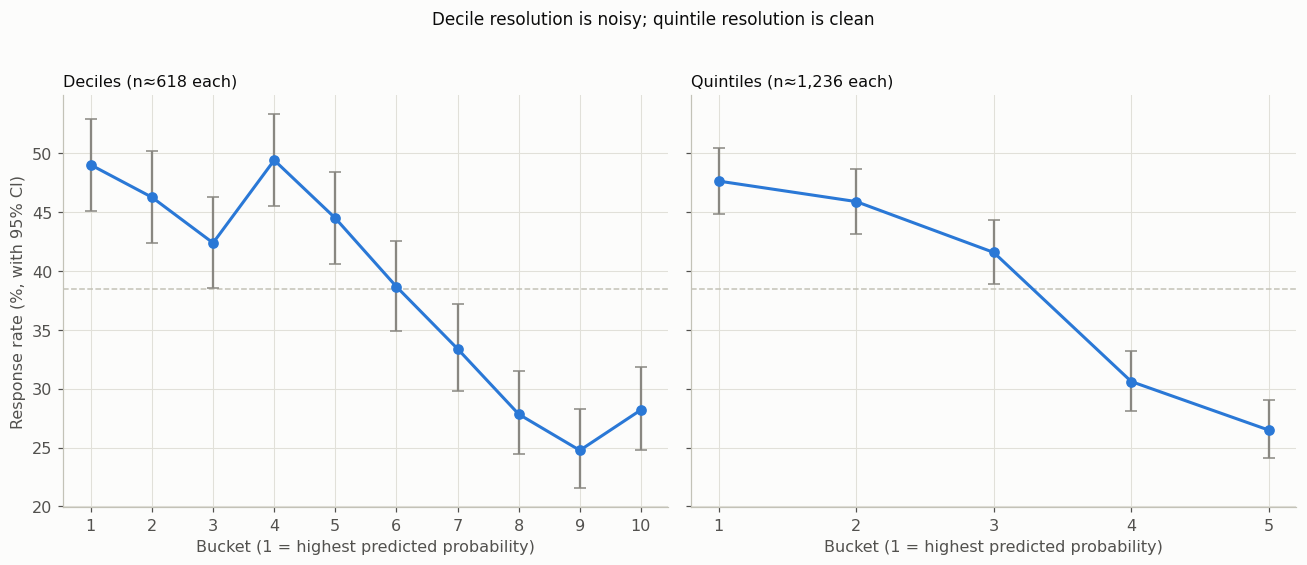

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, table, title in [(axes[0], decile_table, "Deciles (n≈618 each)"),
                          (axes[1], quintile_table.rename(columns={"Bucket": "Decile"}), "Quintiles (n≈1,236 each)")]:
    x = table["Decile"]
    y = table["Response Rate"] * 100
    lo = y - table["CI Lower"] * 100
    hi = table["CI Upper"] * 100 - y
    ax.errorbar(x, y, yerr=[lo, hi], fmt="o-", color=BLUE, ecolor=MUTED,
                elinewidth=1.5, capsize=4, markersize=6, linewidth=2, zorder=3)
    ax.axhline(BASE_RATE * 100, color=AXIS, linewidth=1, linestyle="--", zorder=2)
    ax.set_title(title, loc="left", fontsize=10.5)
    ax.set_xlabel("Bucket (1 = highest predicted probability)")
    ax.set_xticks(x)

axes[0].set_ylabel("Response rate (%, with 95% CI)")
plt.suptitle("Decile resolution is noisy; quintile resolution is clean", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## Conclusion: decile-level targeting is not defensible here

**Deciles:** every flagged reversal's 95% CI overlaps — the choppy staircase
is statistically consistent with noise at n≈618/decile, not proof of a real
ranking failure, but also not evidence the ordering is trustworthy at that
resolution either. The confidence intervals are simply too wide (±4-5 points
on a point estimate) relative to the gaps between adjacent deciles to support
decile-by-decile differentiation.

**Quintiles:** the point estimates become a clean, strictly monotonic
staircase (47.7% → 45.9% → 41.6% → 30.6% → 26.5%) — the reversals disappear
entirely once buckets are large enough. But monotonic point estimates aren't
the same as statistically distinct ones: of the four adjacent quintile
pairs, only quintile 3 vs. quintile 4 clears non-overlap; the rest still
overlap. **Quintile grouping fixes the ordering but doesn't fully resolve the
noise** — it shows the underlying signal is real and directionally
consistent (not a coin flip that happened to cancel out at decile
resolution), but adjacent-quintile differentiation still isn't fully proven.

**Tertiles:** same pattern, one clean level up — monotonic (46.1% → 42.0% →
27.3%), and the top-vs-middle gap still overlaps while the middle-vs-bottom
gap is clean.

**What is robustly supported at every grouping tried:** a real, meaningful
separation between the *top* group and the *bottom* group — roughly top 20%
at ~48% response vs. bottom 20-30% at ~25-26%, consistent with the model's
0.598 AUC (real but modest discrimination, not none).

**Answer to the actual question:** decile-level targeting is not defensible
with this model and this test-set size — treat any specific decile-vs-decile
difference as noise. Quintile grouping is the right minimum resolution for
the P&L layer: it removes the literal reversals and reflects real,
reproducible signal, even though not every adjacent quintile gap is itself
statistically airtight. Tertile is the safer choice if the P&L logic needs
every adjacent-bucket gap to be individually defensible rather than just the
overall trend — the honest position is that **fine-grained (decile) targeting
overstates what this model can support; quintile is where the signal starts
being trustworthy, and tertile is where it's most defensible bucket-to-bucket,
not just end-to-end.**